In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('height-weight.csv')

In [4]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


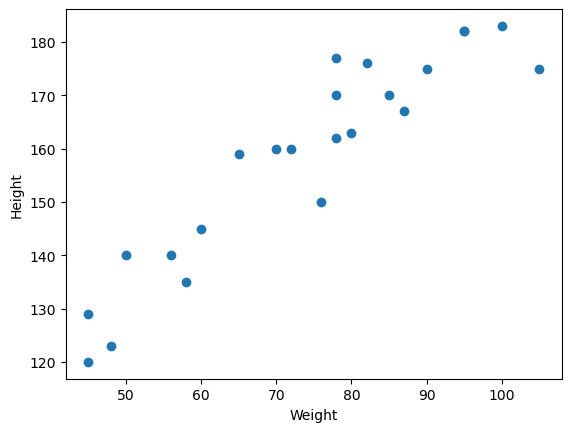

In [5]:
plt.scatter(df.Weight , df.Height)
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

In [6]:
#Problem statement >> I WANT TO PREDICT height based on weight

In [7]:
#Divide the data in x and y
X = df[['Weight']]
Y = df['Height']

In [8]:
X

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [9]:
Y

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, Y_train, Y_test = train_test_split( X , Y , test_size = 0.25 , random_state = 1)

In [12]:
X_train

,Weight
10,82
4,70
2,48
18,76
6,80
7,90
1,58
14,85
0,45
15,78


In [13]:
X_test

,Weight
20,45
17,65
3,60
13,100
19,87
16,50


In [14]:
Y_train

10    176
4     160
2     123
18    150
6     163
7     175
1     135
14    170
0     120
15    177
22    160
21    140
9     170
8     182
12    175
11    182
5     162
Name: Height, dtype: int64

In [17]:
Y_test

20    129
17    159
3     145
13    183
19    167
16    140
Name: Height, dtype: int64

In [18]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((17, 1), (6, 1), (17,), (6,))

In [19]:
#Scaling(Optional >>Standardisation >>>fit transfrom on train data & transform on test data
#if you use fit on test data That is wrong you are doing data leakage , avoid it


In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
scaler = StandardScaler()

In [22]:
scaler

StandardScaler()

In [23]:
X_train

,Weight
10,82
4,70
2,48
18,76
6,80
7,90
1,58
14,85
0,45
15,78


In [24]:
#Scaling should be done always after train test split
#target should not be scaled
#Avoid scaling categorical features
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test)

In [25]:
X_train

array([[ 0.37554243],
       [-0.36825034],
       [-1.73187043],
       [ 0.00364604],
       [ 0.25157697],
       [ 0.87140428],
       [-1.11204312],
       [ 0.56149062],
       [-1.91781863],
       [ 0.12761151],
       [-0.24428488],
       [-1.23600858],
       [ 0.12761151],
       [ 1.18131794],
       [ 1.80114525],
       [ 1.18131794],
       [ 0.12761151]])

In [30]:
X_test

array([[-1.91781863],
       [-0.678164  ],
       [-0.98807766],
       [ 1.49123159],
       [ 0.68545609],
       [-1.60790497]])

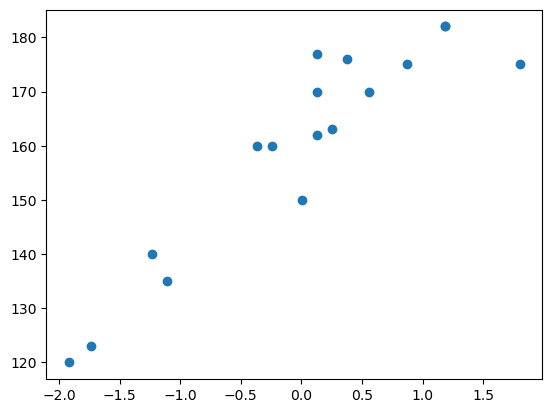

In [31]:
#Scaling is optionla >> it doesnt affect the disribution of data
plt.scatter(X_train , Y_train)

In [33]:
#Model Training

from sklearn.linear_model import LinearRegression
#linear regression parammeters
#fit_intercept >> the best fit line will have intercept coz bydefault it is true
#copy_X >> copy the original X_train and then build the model , it will not modify the original data
#n_jobs >> you want to use all the processors
#positive >> if you set ti True , forces coefficient to be positive

#fit>> train the model
#predict >> test the model

#after building the model , you have attributes of the model
#coef_
#intercept

In [34]:
regressor = LinearRegression()

In [35]:
regressor

LinearRegression()

In [36]:
regressor.fit(X_train , Y_train)

LinearRegression()

In [37]:
regressor.coef_

array([17.7307072])

In [38]:
regressor.intercept_

np.float64(160.0)

In [39]:
print('The slope or coef of the model is' , regressor.coef_)
print('The intercept of the model is' , regressor.intercept_)

The slope or coef of the model is [17.7307072]
The intercept of the model is 160.0


In [40]:
#Prediction on train data

#interpretation of coef>> one unit incr. in weight , on an average the heiht increase by 17.73 units
#predicted height ( y) on X_train = 160 + 17.73 * (X_train)
#predicted height ( y) on X_test = 160 + 17.73 * (X_test)

In [42]:
#prediction on train data
regressor.predict(X_train)

array([166.65863288, 153.47066096, 129.29271243, 160.06464692,
       164.46063756, 175.45061417, 140.28268904, 169.95562586,
       125.99571945, 162.26264224, 155.66865628, 138.08469371,
       162.26264224, 180.94560247, 191.93557907, 180.94560247,
       162.26264224])

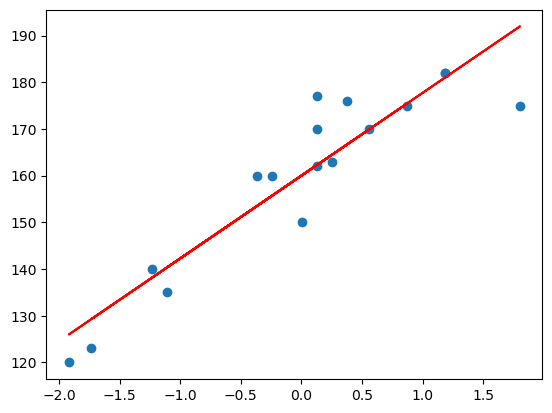

In [45]:
plt.scatter(X_train , Y_train)
plt.plot(X_train , regressor.predict(X_train) , color = 'r')

In [46]:
y_pred_test = regressor.predict(X_test)

In [47]:
y_pred_test , Y_test

(array([125.99571945, 147.97567266, 142.48068436, 186.44059077,
        172.15362118, 131.49070775]),
 20    129
 17    159
 3     145
 13    183
 19    167
 16    140
 Name: Height, dtype: int64)

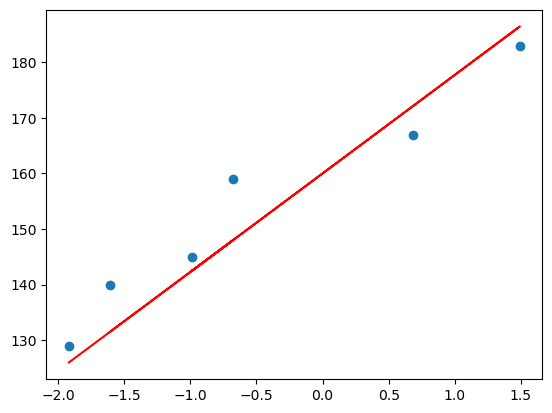

In [48]:
plt.scatter(X_test , Y_test)
plt.plot(X_test , regressor.predict(X_test) , color = 'r')

In [49]:
#Performance metrics
#model evaluaton

from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
mean_squared_error(Y_test , y_pred_test)

41.28566283045539

In [50]:
mean_absolute_error(Y_test , y_pred_test)

5.608571289304824

In [56]:
rsq = r2_score(Y_test ,y_pred_test) # rqaure = 1-SSR/SST
rsq

0.872103617425661

In [57]:
#adjusted Rsquare is given by [1-(1-R2)*n-1/n-k-1)] #n is number of observation and k is no of predictor of variables

In [58]:
X_test.shape[0]

6

In [63]:
1-(1-rsq)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1)

#adjusted rsq will be lesser than rsq

0.8401295217820762

In [64]:
#assumption
#X-y should have linear relationship
#Observation should have no relation
#error should have constant variation
#error should be normally distributed
#features among themself should be least related

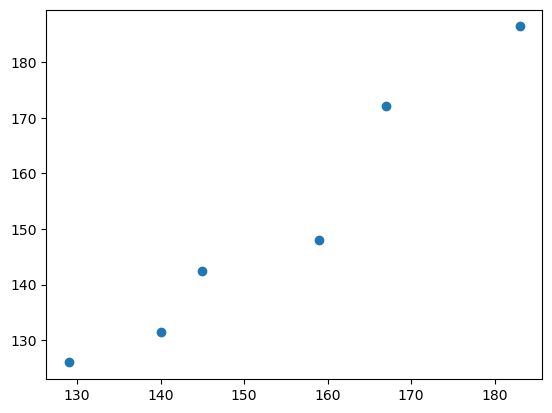

In [67]:
plt.scatter(Y_test,y_pred_test) # to check ytest and its prediction aligns

In [68]:
#error should have constant variation
#error should be normally distributed

In [71]:
error = Y_test-y_pred_test
error

20     3.004281
17    11.024327
3      2.519316
13    -3.440591
19    -5.153621
16     8.509292
Name: Height, dtype: float64